#### H**uman Emotion Detection From Images**

##### Loading images:

In [1]:
import os
import cv2
import numpy as np

In [2]:
data_path = "Dataset/CK+48"

In [3]:
data_list = os.listdir(data_path)
data_list

['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']

In [4]:
img_data = []

for dataset in data_list:
    img_list = os.listdir(data_path + "/" + dataset)
    print("Loading images from dataset: ", dataset)
    print(f"Dataset: {dataset} | Number of images: {len(img_list)}")
    for img in img_list:
        img_path = data_path + "/" + dataset + "/" + img
        input_img = cv2.imread(img_path)
        input_resized_img = cv2.resize(input_img, (48, 48))
        img_data.append(input_resized_img)




Loading images from dataset:  anger
Dataset: anger | Number of images: 135
Loading images from dataset:  contempt
Dataset: contempt | Number of images: 54
Loading images from dataset:  disgust
Dataset: disgust | Number of images: 177
Loading images from dataset:  fear
Dataset: fear | Number of images: 75
Loading images from dataset:  happy
Dataset: happy | Number of images: 207
Loading images from dataset:  sadness
Dataset: sadness | Number of images: 84
Loading images from dataset:  surprise
Dataset: surprise | Number of images: 249


In [5]:
data = np.array(img_data) # here we are converting the list of images into a numpy array for further processing.
data = data.astype("float32") # Here we are converting the data type of the numpy array to float32 for further processing.
data = data / 255.0 # Here we are normalizing the pixel values of the images to be in the range of 0 to 1 by dividing by 255.0.
data.shape

(981, 48, 48, 3)

##### preparing the data

In [14]:
from tensorflow.keras.utils import to_categorical 
from sklearn.utils import shuffle 
from sklearn.model_selection import train_test_split

In [15]:
num_classes = len(data_list)
num_samples = data.shape[0]

In [21]:
# one hot encoding of the labels
labels = np.ones((num_samples,), dtype='int64')

In [22]:
labels[0:135] = 0 # Angry
labels[135:189] = 1 # comtempt
labels[189:366] = 2 # disgust
labels[366:441] = 3 # fear
labels[441:648] = 4 # happy
labels[648:732] = 5 # sadness
labels[732:981] = 6 # surprise

In [25]:
names = data_list
img_labels = to_categorical(labels, num_classes) # one hot encoding of the labels

In [31]:
img_labels[850]

array([0., 0., 0., 0., 0., 0., 1.])

In [33]:
# shuffling the data and labels to ensure that the model does not learn any patterns based on the order of the data.
X_img, y_img = shuffle(data, img_labels, random_state=2)

In [35]:
# preparing the data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(X_img, y_img, test_size=0.2, random_state=2)

##### Showing Some Samples of Images

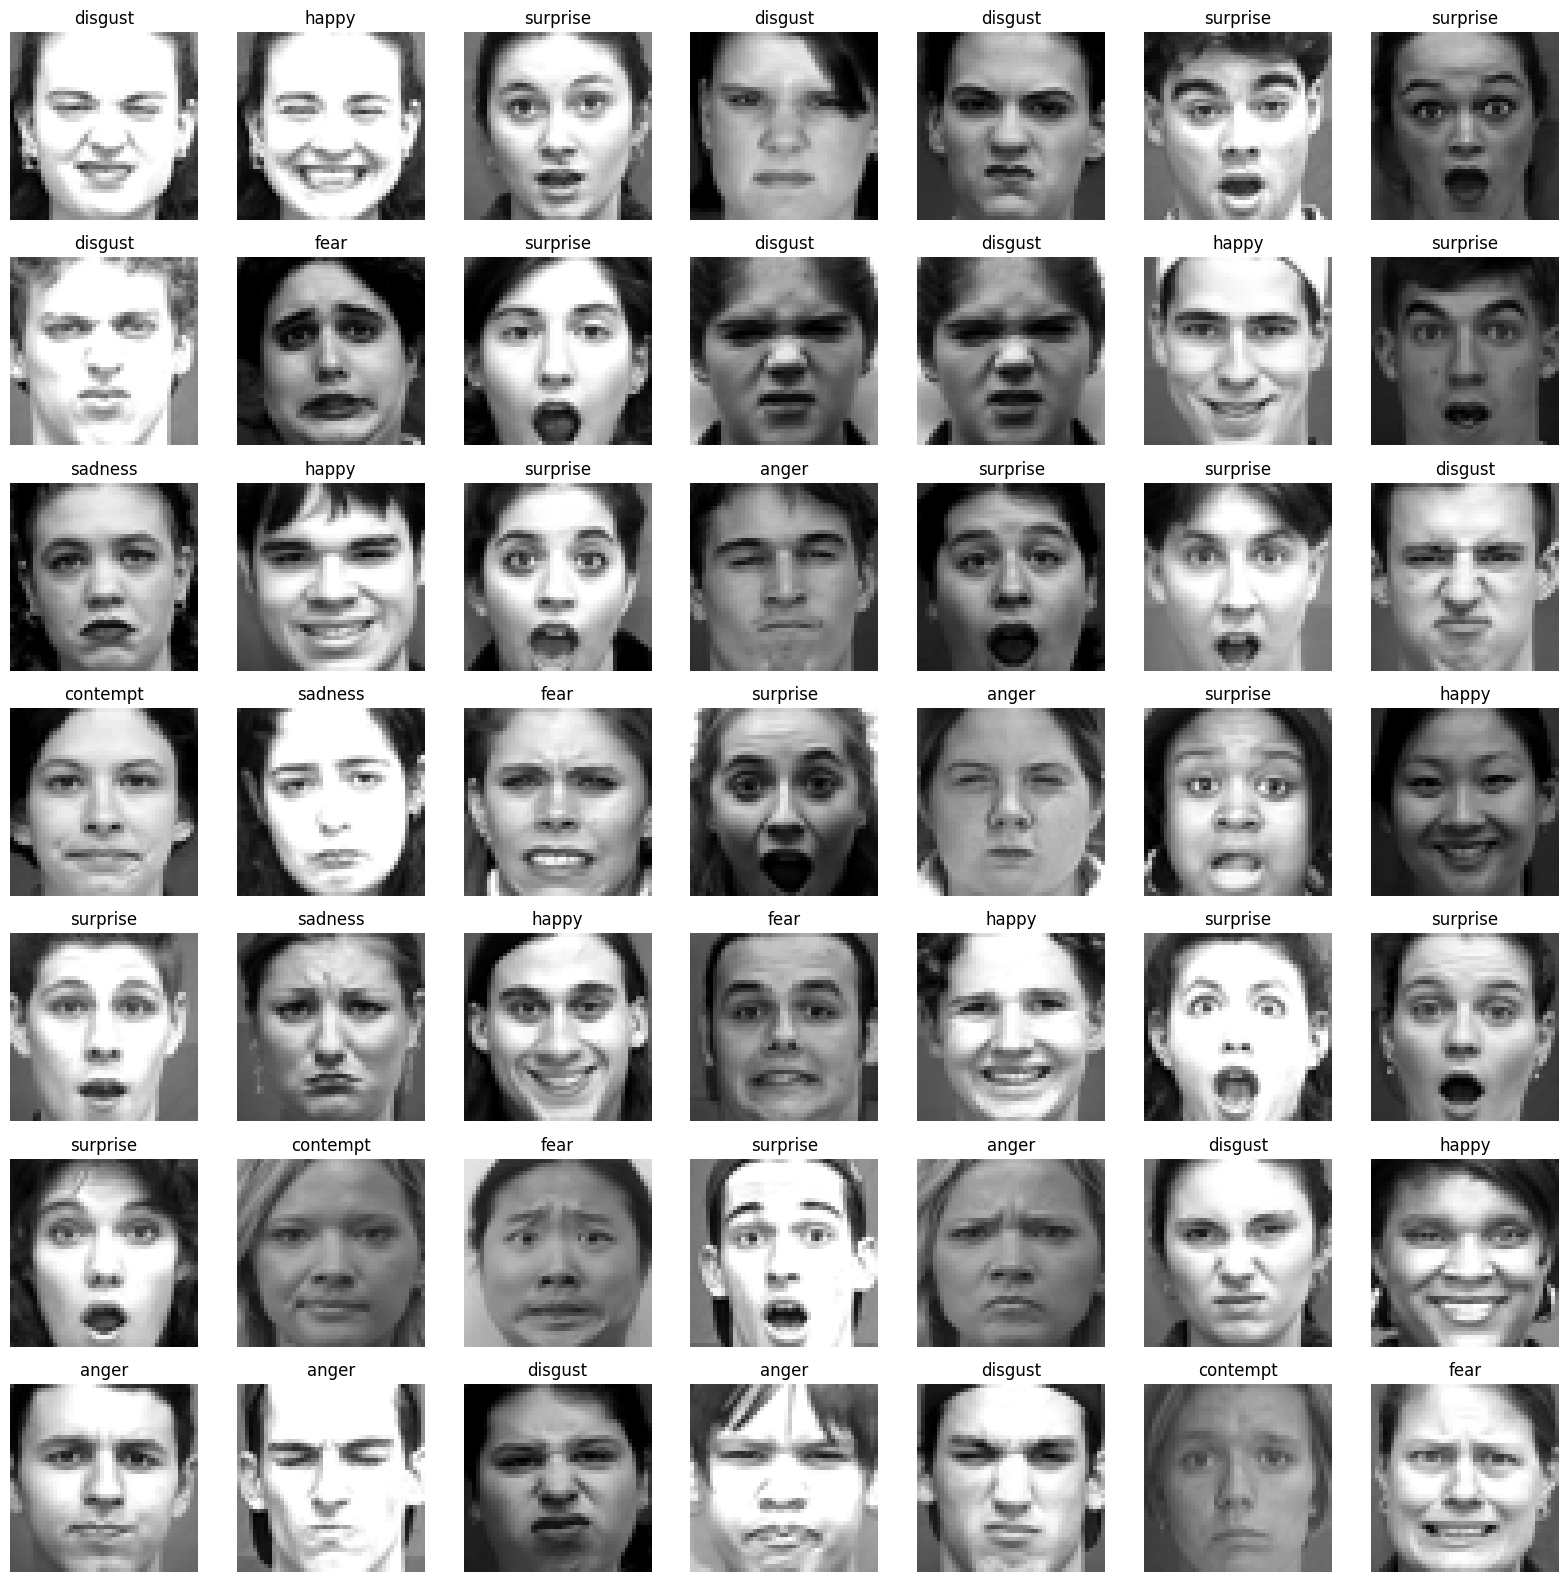

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
for i,j in enumerate(np.random.randint(0, len(X_img), 49)):
    plt.subplot(7, 7, i+1)
    plt.imshow(X_img[j])
    plt.title(names[np.argmax(y_img[j])])
    plt.axis('off')

##### **Building CNN Model**

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout
from tensorflow.keras.layers import Activation, Flatten

In [49]:
def create_model():
    input_shape = (48, 48, 3)
    
    model = Sequential()
    
    model.add(Conv2D(6, (5, 5), padding='same', input_shape=input_shape, activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Conv2D(16, (5, 5), padding='same', activation='relu'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Flatten())
    
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(7, activation='softmax'))
    

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    return model

In [50]:
model = create_model()
model.summary()

/home/muh7/.pyenv/versions/ai_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1790656198.317390 1987892 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 308,095 (1.18 MB)

 Trainable params: 308,095 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

##### **Plot the deep learning model**

In [51]:
from tensorflow.keras.utils import plot_model

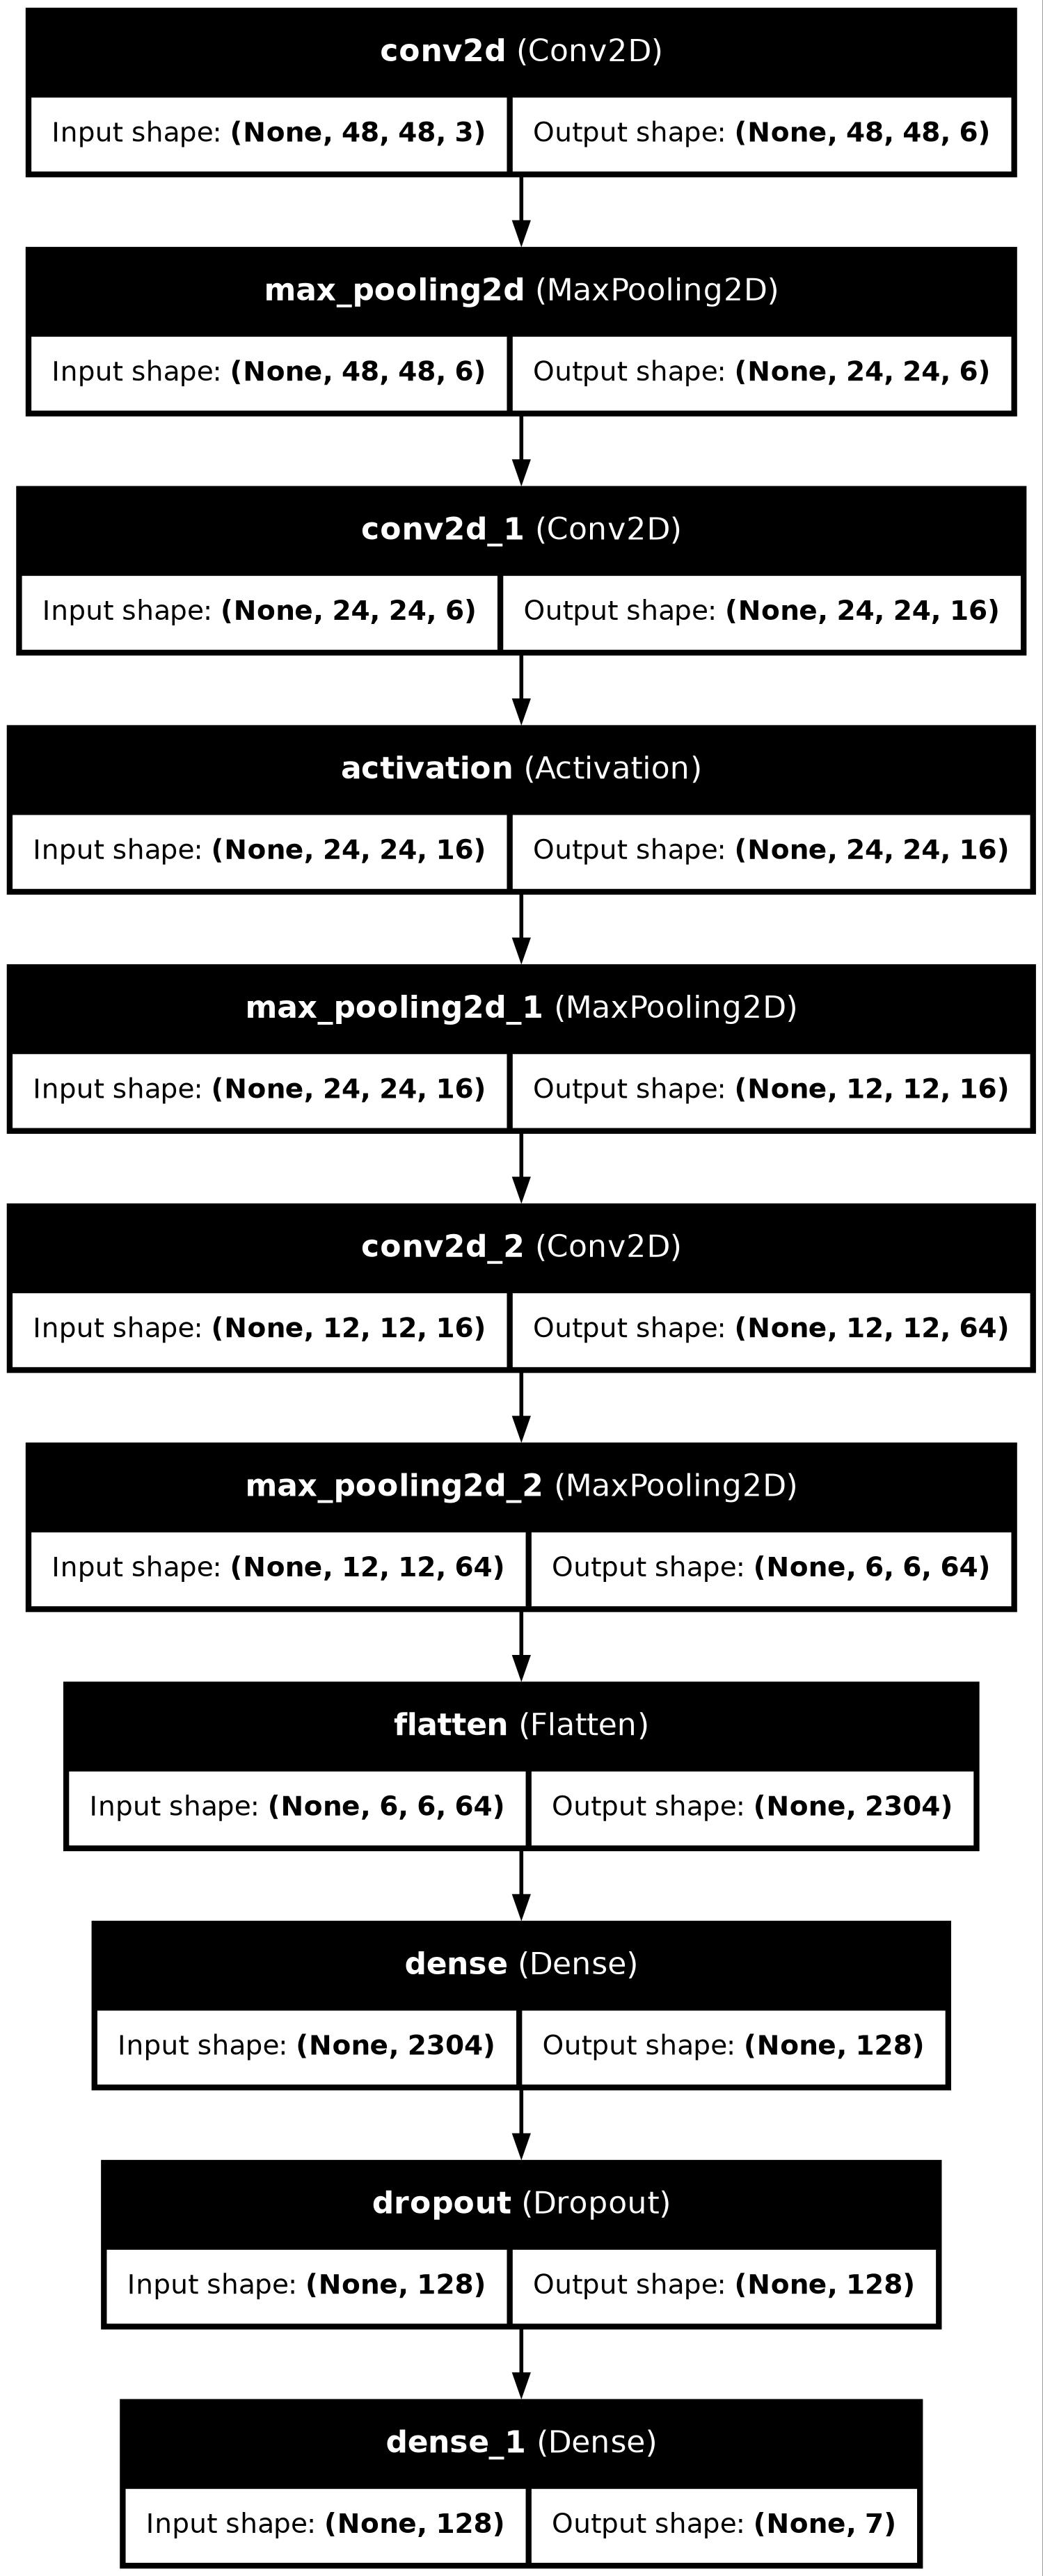

In [52]:
plot_model(model, to_file='my_model.jpg', show_shapes=True, show_layer_names=True)

##### **Training the model**

In [88]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [89]:
train_generator = train_datagen.flow(
    x_train,
    y_train,
    batch_size=32,
    shuffle=True
)

test_generator = test_datagen.flow(
    x_test,
    y_test,
    batch_size=32,
    shuffle=False
)

In [90]:
history = model.fit(train_generator, batch_size=32, epochs=200, validation_data=test_generator, shuffle=True)

Epoch 1/200


I0000 00:00:1790661789.139529 1987892 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1824 - loss: 1.9313 - val_accuracy: 0.3096 - val_loss: 1.7413
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2117 - loss: 1.8903 - val_accuracy: 0.3096 - val_loss: 1.7771
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2232 - loss: 1.8747 - val_accuracy: 0.3096 - val_loss: 1.7682
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2360 - loss: 1.8699 - val_accuracy: 0.3096 - val_loss: 1.7768
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2309 - loss: 1.8521 - val_accuracy: 0.3096 - val_loss: 1.7398
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2423 - loss: 1.8496 - val_accuracy: 0.3096 - val_loss: 1.7503
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2500 - loss: 1.8500 - val_accuracy: 0.3096 - val_loss: 1.7562
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2538 - loss: 1.8533 - val_accuracy: 0.3096 - val_l

##### **Testing**

In [95]:
loss, score = model.evaluate(x_test, y_test, verbose=1)
print("The accuracy for testing: %f" % (score*100), "%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6497 - loss: 117.0160 
The accuracy for testing: 64.974618 %


In [96]:
x_test[0].shape

(48, 48, 3)

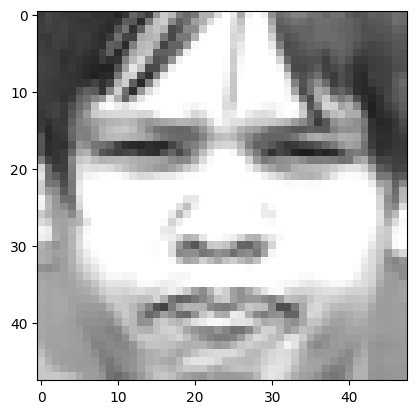

In [97]:
import matplotlib.pyplot as plt
plt.imshow(x_test[0])

In [98]:
pre = model.predict(x_test[0].reshape(1, 48, 48, 3))
pre

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([[0., 0., 0., 0., 1., 0., 0.]], dtype=float32)

In [99]:
names[list(pre.astype(int).flatten()).index(1)]

'happy'

Text(0.5, 1.0, 'happy')

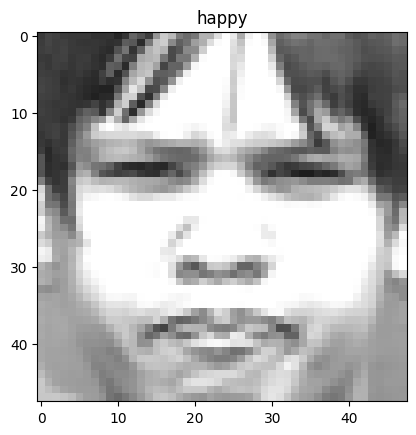

In [100]:
plt.imshow(x_test[0])
plt.title(names[list(pre.astype(int).flatten()).index(1)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


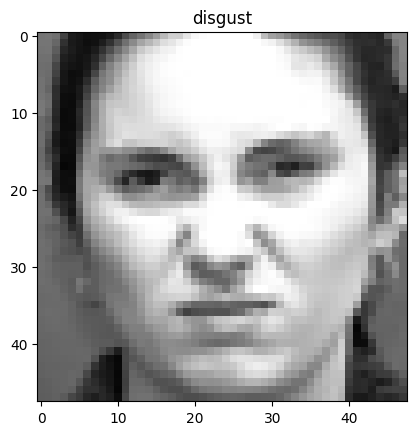

In [101]:
def predict_emotion(index):
    image = x_test[index]
    pre = model.predict(image.reshape(1, 48, 48, 3))
    plt.imshow(image)
    plt.title(names[list(pre.astype(int).flatten()).index(1)])
    plt.show()

predict_emotion(5)

##### **Comparison & Plot Lossess values**

<Figure size 640x480 with 0 Axes>

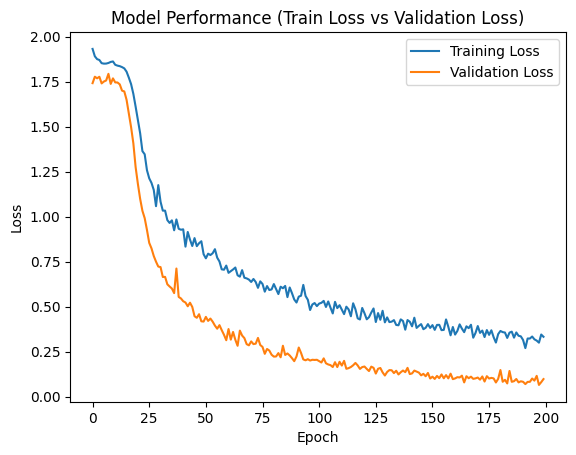

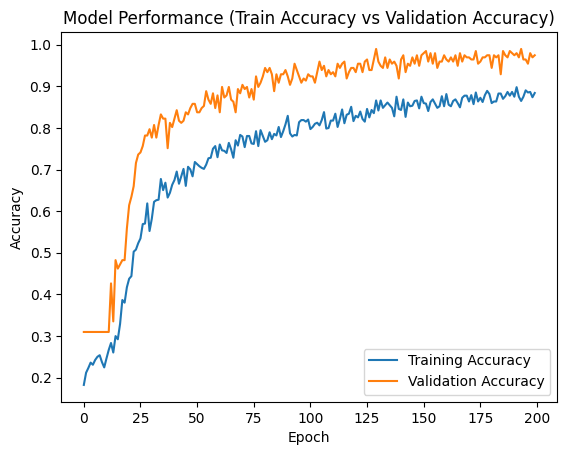

<Figure size 640x480 with 0 Axes>

In [102]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

steps = range(len(train_loss))
plt.plot(steps, train_loss, label='Training Loss')
plt.plot(steps, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Performance (Train Loss vs Validation Loss)')
plt.legend()
plt.figure()


plt.plot(steps, history.history['accuracy'], label='Training Accuracy')
plt.plot(steps, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Performance (Train Accuracy vs Validation Accuracy)')
plt.legend()
plt.figure()

Predicted emotion: anger
Confidence: 1.0


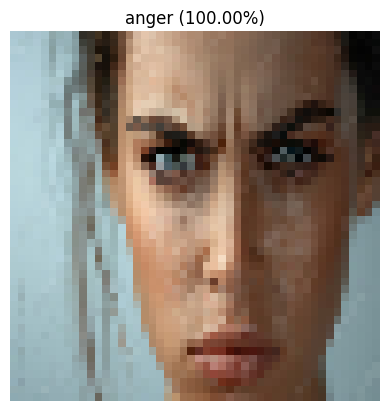

In [123]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("ann.jpg")

# Resize to the same size used during training
img = cv2.resize(img, (48, 48))

# Convert to float32 and normalize
img = img.astype("float32") / 255.0

# Add batch dimension: (48,48,3) -> (1,48,48,3)
test_image = np.expand_dims(img, axis=0)

# Predict
pred = model.predict(test_image, verbose=0)

# Get predicted class
predicted_class = np.argmax(pred[0])

# Get emotion name
predicted_emotion = names[predicted_class]

print("Predicted emotion:", predicted_emotion)
print("Confidence:", pred[0][predicted_class])

# Display
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"{predicted_emotion} ({pred[0][predicted_class]:.2%})")
plt.axis("off")
plt.show()